## Clone Hub Repo

In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 4.84 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Upload dataset


In [ ]:
data_path = "/content/drive/MyDrive/GP_datasets/Baron_Pancreas_Human_mix.h5ad"

## Run UCE model on loaded data

In [ ]:
! python eval_single_anndata.py --adata_path {data_path} --dir "./" --model_loc "minwoosun/uce-100m"


species_chrom.csv: 4.10MB [00:00, 16.2MB/s]
all_tokens.torch: 100% 2.98G/2.98G [00:22<00:00, 135MB/s]
species_offsets.pkl: 100% 139/139 [00:00<00:00, 191B/s]
protein_embeddings/Danio_rerio.GRCz11.ge(…): 100% 537M/537M [00:03<00:00, 143MB/s]
protein_embeddings/Homo_sapiens.GRCh38.g(…): 100% 411M/411M [00:04<00:00, 100MB/s] 
protein_embeddings/Macaca_fascicularis.M(…): 100% 315M/315M [00:03<00:00, 104MB/s]
protein_embeddings/Macaca_mulatta.Mmul_1(…): 100% 348M/348M [00:02<00:00, 156MB/s]
protein_embeddings/Microcebus_murinus.Mm(…): 100% 302M/302M [00:04<00:00, 65.6MB/s]
protein_embeddings/Mus_musculus.GRCm39.g(…): 100% 464M/464M [00:01<00:00, 234MB/s]
protein_embeddings/Sus_scrofa.Sscrofa11.(…): 100% 327M/327M [00:02<00:00, 120MB/s]
protein_embeddings/Xenopus_tropicalis.Xe(…): 100% 281M/281M [00:02<00:00, 96.9MB/s]
Download Complete!
Proccessing Baron_Pancreas_Human_mix
3298.0
Baron_Pancreas_Human_mix (8569, 11300)
Wrote Shapes Dict
11300
Max Code: 613
config.json: 100% 115/115 [00:00<00

In [ ]:
!pip install umap-learn matplotlib

In [ ]:
import scanpy as sc

# Read the .h5ad file
adata = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Pancreas_combined_Human_embeddings_uce.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 8569 × 11300
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'n_genes', 'disease'
    var: 'n_cells'
    uns: 'cell_type_colors', 'disease_colors', 'donor_id_colors', 'neighbors', 'umap'
    obsm: 'X_uce', 'X_umap'
    obsp: 'connectivities', 'distances'


# Build a cell-type classifier using UCE embeddings

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_uce"]
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

=== Logistic Regression ===
Accuracy: 0.9218111798342864
                    precision    recall  f1-score   support

            acinar       0.95      0.97      0.96       958
activated_stellate       0.95      0.97      0.96       284
             alpha       0.88      0.99      0.93      2326
              beta       0.95      0.98      0.97      2525
             delta       0.80      0.61      0.69       601
            ductal       0.96      0.95      0.96      1077
       endothelial       1.00      0.98      0.99       252
           epsilon       0.00      0.00      0.00        18
             gamma       0.90      0.17      0.28       255
        macrophage       0.98      0.93      0.95        55
              mast       1.00      1.00      1.00        25
quiescent_stellate       0.95      0.92      0.94       173
           schwann       1.00      0.62      0.76        13
            t_cell       0.00      0.00      0.00         7

          accuracy                       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


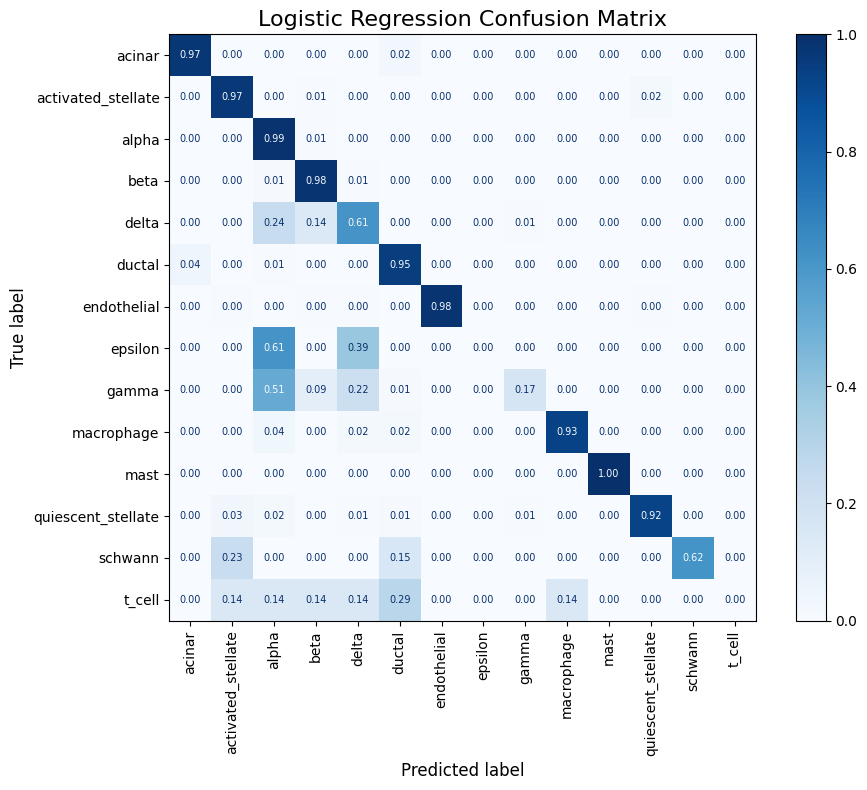


=== k-NN ===
Accuracy: 0.9048897187536469
                    precision    recall  f1-score   support

            acinar       0.97      0.98      0.97       958
activated_stellate       0.95      0.96      0.96       284
             alpha       0.81      0.99      0.89      2326
              beta       0.95      0.98      0.96      2525
             delta       0.84      0.37      0.52       601
            ductal       0.98      0.96      0.97      1077
       endothelial       1.00      0.99      1.00       252
           epsilon       0.00      0.00      0.00        18
             gamma       0.81      0.09      0.16       255
        macrophage       1.00      0.93      0.96        55
              mast       0.96      1.00      0.98        25
quiescent_stellate       0.92      0.91      0.92       173
           schwann       1.00      0.92      0.96        13
            t_cell       1.00      0.71      0.83         7

          accuracy                           0.90      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


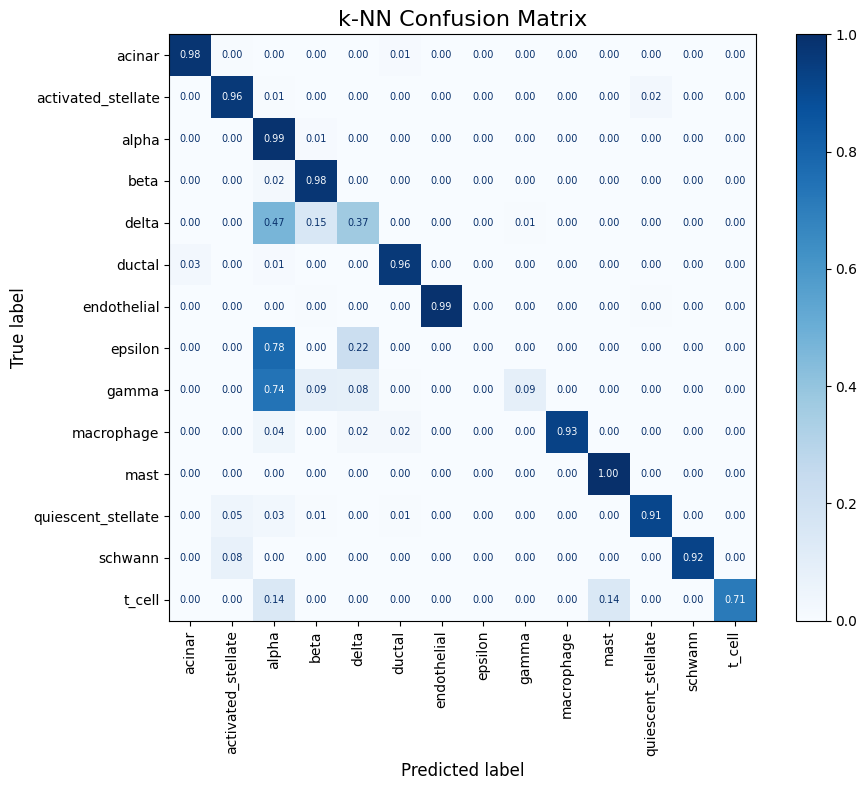

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")

print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

# Visualize UCE embeddings through UMAP

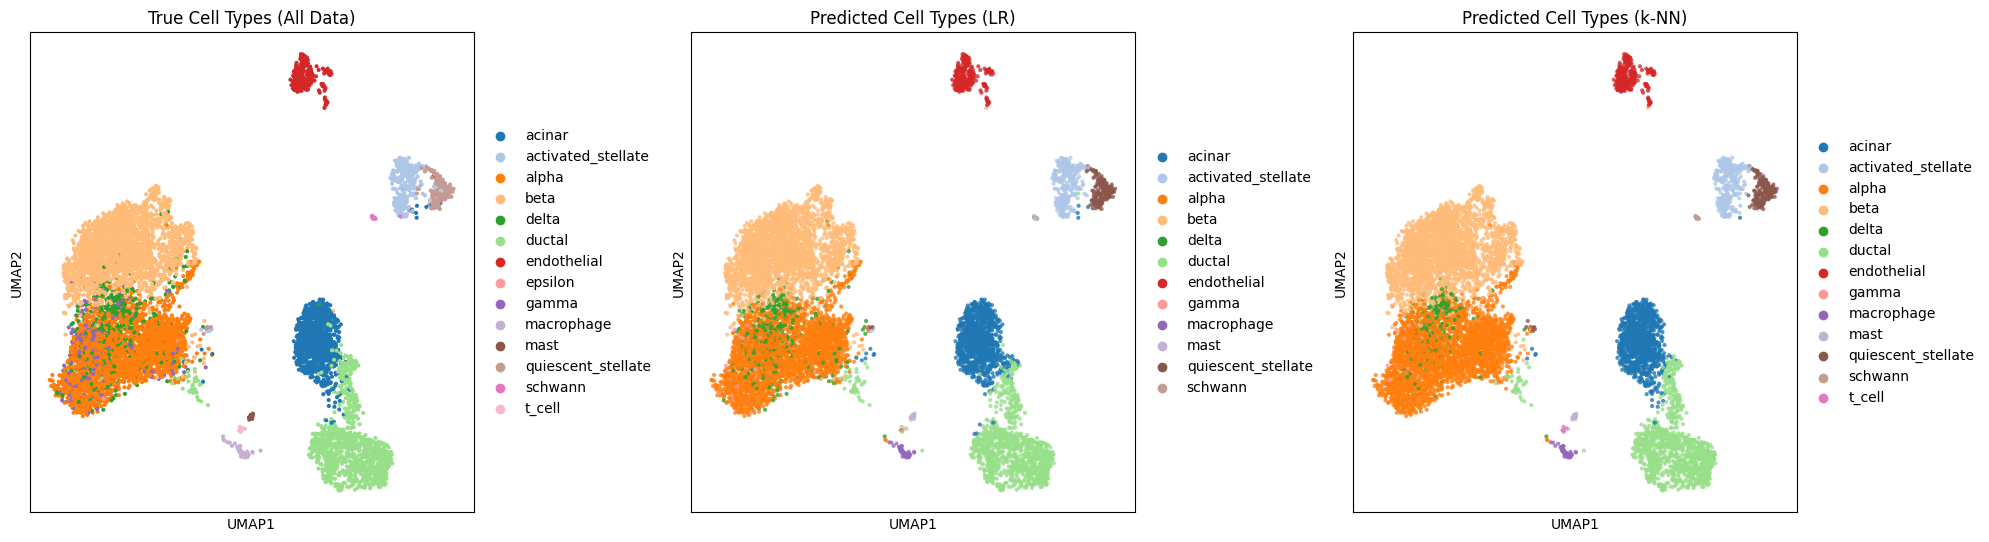

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')
#neighbors + UMAP on full data
sc.pp.neighbors(adata, use_rep='X_uce', n_neighbors=15)
sc.tl.umap(adata)


# Create side-by-side figure

# Unified label categories
all_labels = pd.Categorical(pd.concat([
    pd.Series(adata.obs['cell_type'].cat.categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_lr']).categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_knn']).categories)
], ignore_index=True)).categories

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map['Unassigned'] = 'lightgray'

# Create side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# True labels
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[0],
    show=False,
    size=35,
    palette=[color_map[x] for x in all_labels],
)
axes[0].set_title('True Cell Types (All Data)')

# Predicted labels (lr)
sc.pl.umap(
    adata,
    color='y_pred_lr',
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.8,
    palette=[color_map[x] for x in all_labels],
)
axes[1].set_title('Predicted Cell Types (LR)')

# Predicted labels (knn)
sc.pl.umap(
    adata,
    color='y_pred_knn',
    ax=axes[2],
    show=False,
    size=35,
    alpha=0.8,
    palette=[color_map[x] for x in all_labels],
)
axes[2].set_title('Predicted Cell Types (k-NN)')

# # Unified legend
# handles = [Patch(color=color_map[label], label=label) for label in all_labels]
# fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
